In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/ai4i2020.csv")
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
df.shape

(10000, 14)

In [3]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [5]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [6]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [7]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [8]:
df["Machine failure"].value_counts(normalize=True)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

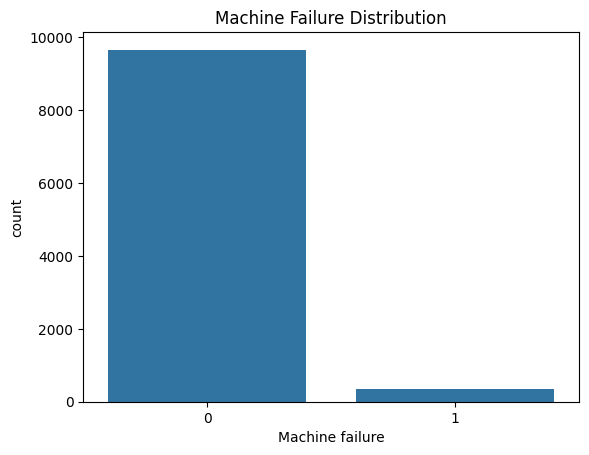

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Machine failure", data=df)
plt.title("Machine Failure Distribution")
plt.show()

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

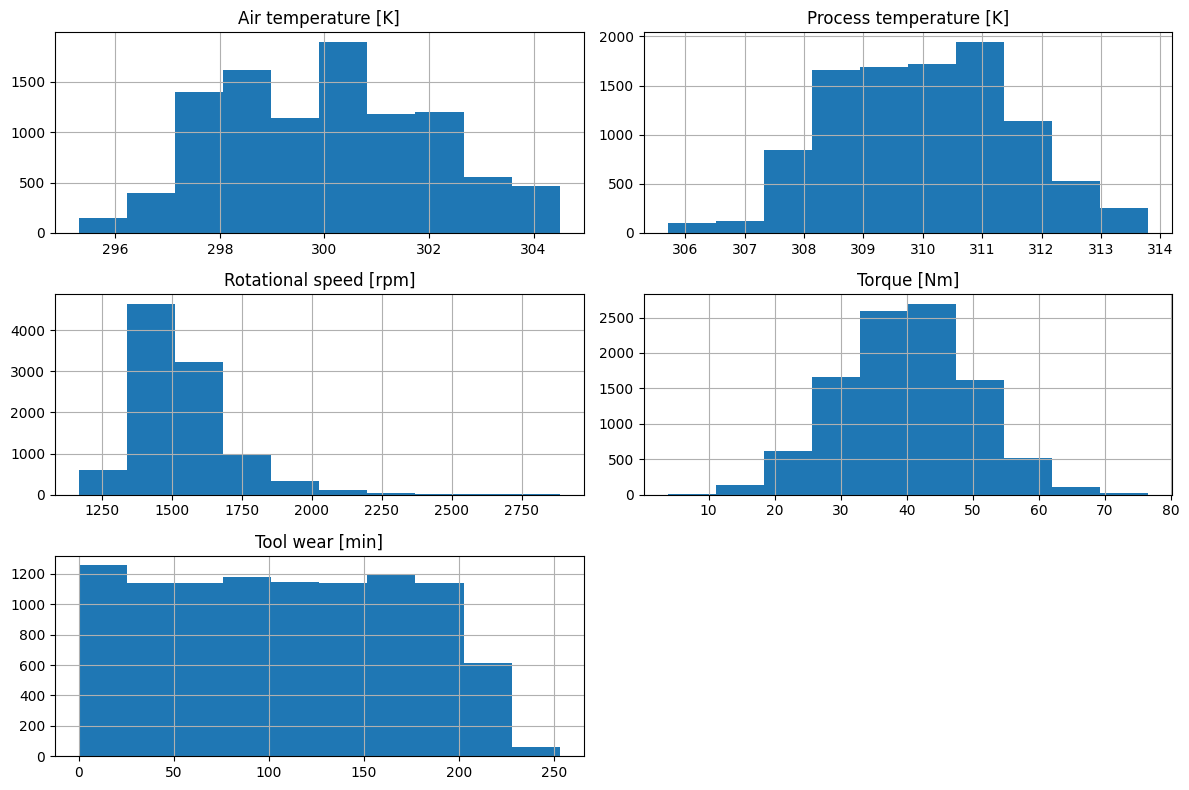

In [11]:
# Select numerical sensor and operating features. 
numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Plot histograms to inspect feature distributions.
df[numerical_features].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

### Numerical Feature Distributions

The dataset contains five main numerical sensor/operating features: air temperature, process temperature, rotational speed, torque, and tool wear.

Air temperature and process temperature are roughly centered around their normal operating ranges. Torque also looks approximately normally distributed. Rotational speed is right-skewed, meaning most machines operate around lower-to-medium speeds, but a few observations have very high RPM values. Tool wear is spread quite evenly from low to high values, which is useful because the dataset contains machines at different wear stages.

These distributions suggest that feature scaling will likely be useful later, especially for models such as logistic regression, neural networks, or distance-based models.

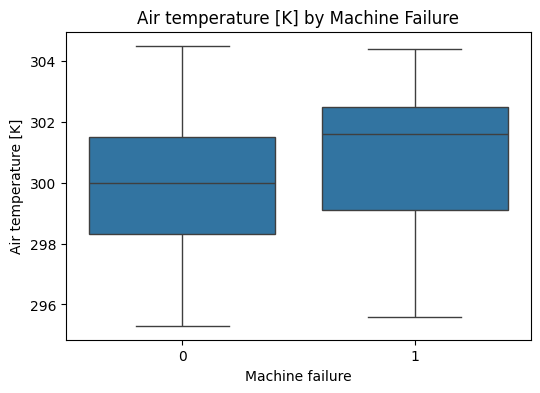

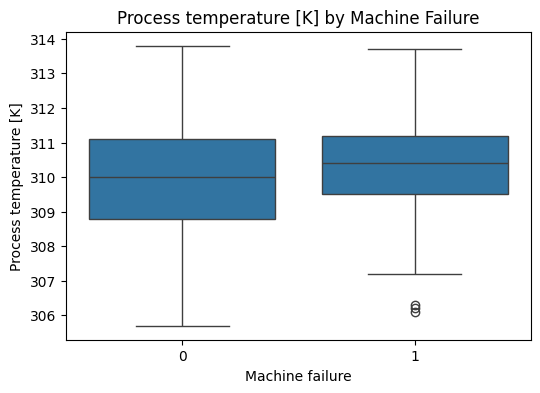

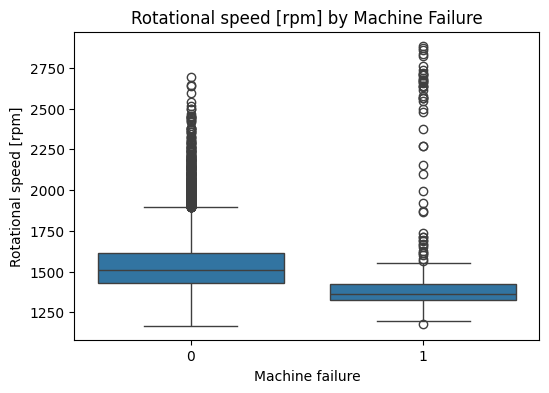

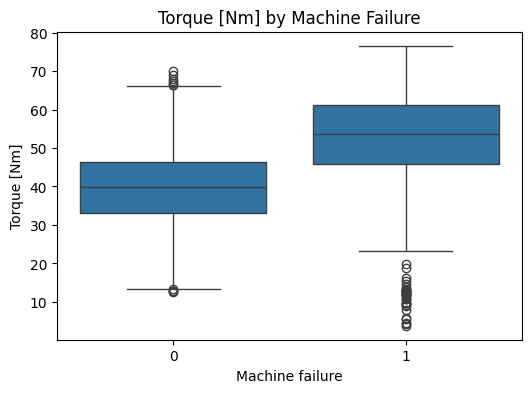

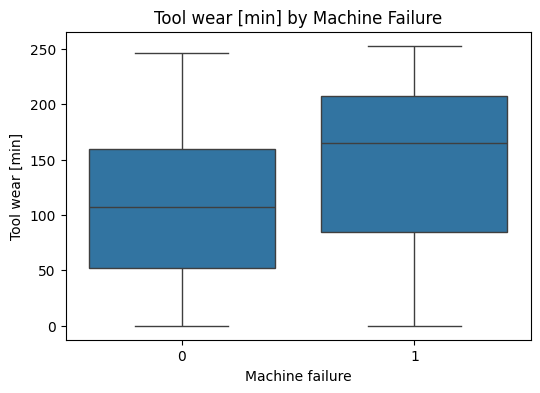

In [12]:
# Comparing those features for failed vs non-failed machines.
for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Machine failure", y=feature, data=df)
    plt.title(f"{feature} by Machine Failure")
    plt.show()

### Comparing Numerical Features for Failed vs Non-Failed Machines

The boxplots compare the distributions of numerical features for normal machines (`0`) and failed machines (`1`).

Several interesting patterns can already be observed:

- Failed machines tend to operate at slightly higher air and process temperatures compared to non-failed machines.
- Machines that failed generally show lower rotational speeds.
- Torque appears noticeably higher for failed machines. This suggests that higher mechanical load may contribute to machine failures.
- Tool wear is also clearly higher in failed machines, indicating that older or more heavily used tools are more likely to fail.

The plots also show several outliers, especially in rotational speed and torque. These extreme operating conditions may represent unusual machine behavior or edge cases that are important for predictive maintenance.

Overall, torque and tool wear already appear to be strong indicators of machine failure and may become important predictive features during model training.

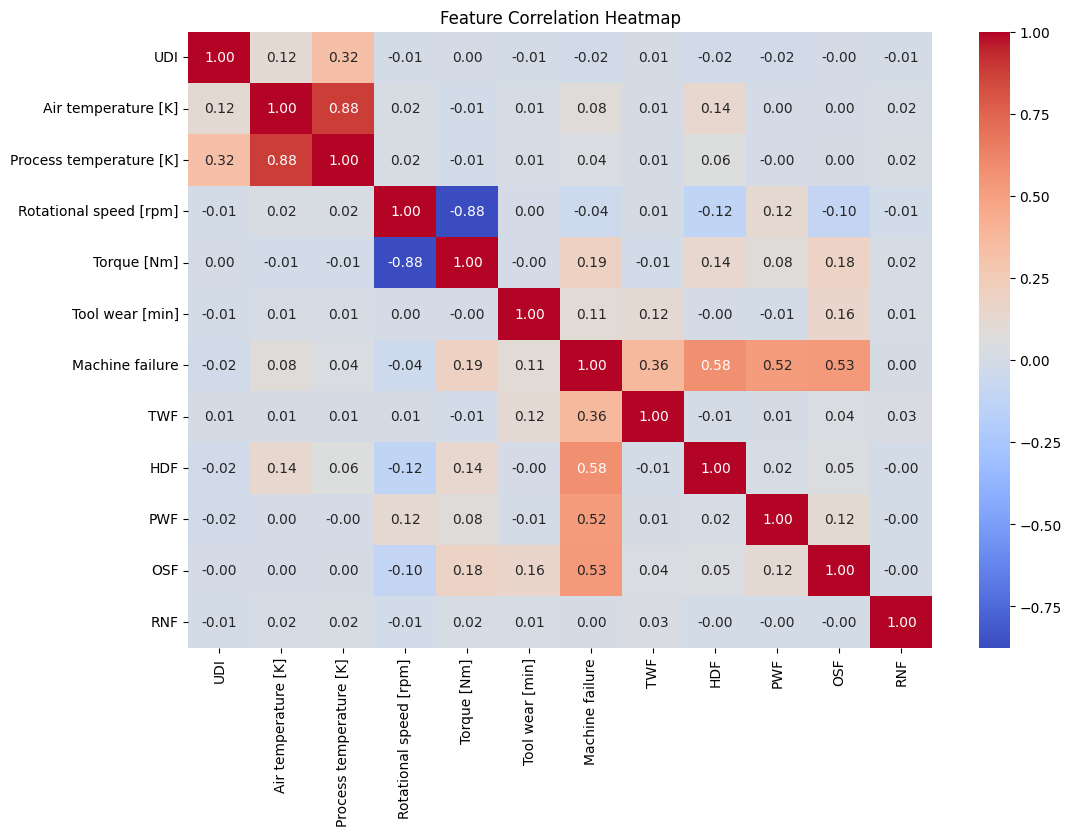

In [13]:
# Compute correlation matrix for numerical columns
correlation_matrix = df.corr(numeric_only=True)

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

### Feature Correlation Analysis

The correlation heatmap shows the linear relationships between numerical features and failure indicators.

Several important relationships can be observed:

- Air temperature and process temperature have a very strong positive correlation (~0.88). This makes sense because machines operating in warmer environments also tend to have higher internal process temperatures.
- Rotational speed and torque have a very strong negative correlation (~-0.88). This suggests that machines operating at lower rotational speeds often experience higher torque loads.
- Torque and tool wear show moderate positive relationships with machine failure. This supports the earlier boxplot observations that failed machines tend to experience higher stress and wear.
- The strongest correlations with machine failure are the specific failure types (`HDF`, `PWF`, `OSF`, etc.), which is expected because they directly describe different categories of failure.
- Most other correlations with machine failure are relatively weak, suggesting that failure prediction may require learning nonlinear combinations of multiple features rather than relying on a single variable.

The heatmap also suggests that some features may contain overlapping information. For example, air temperature and process temperature are highly correlated, which could become relevant during feature engineering or model selection.

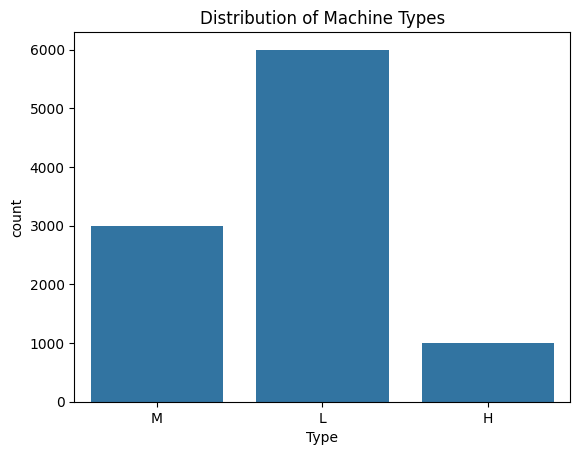

In [14]:
# Distribution of machine types
sns.countplot(x="Type", data=df)
plt.title("Distribution of Machine Types")
plt.show()

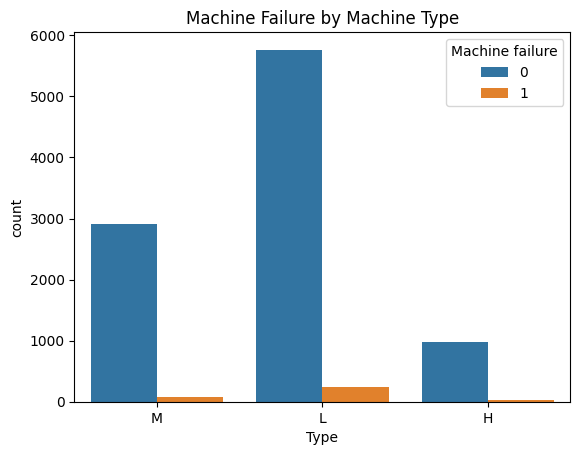

In [15]:
# Machine failure by type
sns.countplot(x="Type", hue="Machine failure", data=df)
plt.title("Machine Failure by Machine Type")
plt.show()

### Analysis of Machine Types

The dataset contains three machine categories:

- `L` = Low quality
- `M` = Medium quality
- `H` = High quality

The first plot shows that the dataset is not evenly distributed across machine types:

- Most machines belong to the `L` category (~6000 samples)
- `M` machines are the second largest group (~3000 samples)
- `H` machines are the smallest group (~1000 samples)

The second plot compares machine failures across these categories.

Important observations:

- `L` machines have the highest number of failures overall.
- `H` machines have the fewest failures.
- However, this may partly be because there are far more `L` machines in the dataset.

This suggests that machine type may influence failure behavior and could become an important feature for the machine learning model later.

Since `Type` is a categorical feature, it cannot be used directly by most ML algorithms. During preprocessing, it will likely need to be encoded into numerical form using techniques such as one-hot encoding or label encoding.

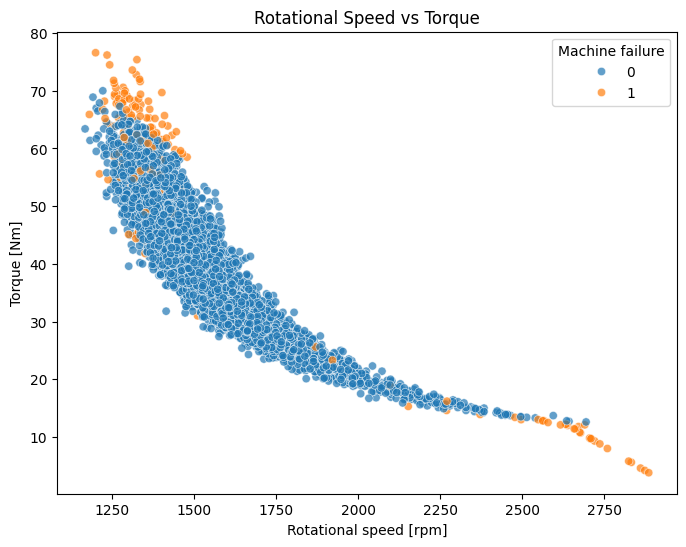

In [16]:
# Scatterplot: rotational speed vs torque
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Rotational speed [rpm]",
    y="Torque [Nm]",
    hue="Machine failure",
    data=df,
    alpha=0.7
)

plt.title("Rotational Speed vs Torque")
plt.show()

### Relationship Between Rotational Speed and Torque

The scatterplot shows a strong negative relationship between rotational speed and torque.

Important observations:

- As rotational speed increases, torque generally decreases.
- This confirms the strong negative correlation observed earlier in the heatmap.
- Failed machines (`1`, shown in orange) appear more frequently in extreme operating regions:
  - very high torque + low rotational speed
  - very high rotational speed + very low torque
- Non-failed machines (`0`) are more concentrated in the middle operating range.

This suggests that machines operating under extreme mechanical conditions are more likely to fail.

The scatterplot also indicates that combinations of features may be more useful for prediction than individual features alone. This is important because machine learning models can learn these multidimensional patterns automatically.